In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 1 — Setup  (Google Colab + local paths)
# ════════════════════════════════════════════════════════════════════════
import os, subprocess, sys

# ── Colab-only: mount Drive ───────────────────────────────────────────
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    GDRIVE = '/content/drive/MyDrive/banksentinel'
    MODELS = f'{GDRIVE}/models'
    PLOTS  = f'{GDRIVE}/plots'
    DATA   = '/content/data'
except ImportError:
    IN_COLAB = False
    # ── LOCAL fallback: set these two paths to match your machine ────
    GDRIVE = os.path.expanduser('~/banksentinel')          # edit if needed
    MODELS = f'{GDRIVE}/models'
    PLOTS  = f'{GDRIVE}/plots'
    DATA   = f'{GDRIVE}/data'

for d in [MODELS, PLOTS, DATA]:
    os.makedirs(d, exist_ok=True)

!pip install xgboost scikit-learn pandas numpy joblib -q

import torch
gpu = torch.cuda.is_available()
print(f"Colab         : {IN_COLAB}")
print(f"GPU available : {gpu}")
print(f"Models dir    : {MODELS}")
print(f"Data dir      : {DATA}")
print("✓  Setup complete")


Mounted at /content/drive
Colab         : True
GPU available : False
Models dir    : /content/drive/MyDrive/banksentinel/models
Data dir      : /content/data
✓  Setup complete


In [ ]:
import shutil, glob
from pathlib import Path

# ── CONFIG — edit this line if you have the data locally ─────────────
CTU_LOCAL_DIR = f'{GDRIVE}/data/ctu13'   # e.g.  "/home/user/datasets/ctu13"  or  ""

CTU_DIR = f'{GDRIVE}/data/ctu13'

if CTU_LOCAL_DIR and Path(CTU_LOCAL_DIR).exists():
    # ── Use local copy (fastest) ──────────────────────────────────────
    print(f"[LOCAL] Using CTU-13 data from: {CTU_LOCAL_DIR}")
    CTU_DIR = CTU_LOCAL_DIR
else:
    # ── Download from Kaggle (Colab or first-run) ─────────────────────
    os.makedirs(CTU_DIR, exist_ok=True)
    KAGGLE_JSON = f'{GDRIVE}/kaggle.json'
    if not os.path.exists(KAGGLE_JSON):
        raise FileNotFoundError(
            "Neither a local CTU-13 folder nor kaggle.json was found.\n"
            "  Option A: set CTU_LOCAL_DIR above to your local dataset path.\n"
            "  Option B: upload kaggle.json to Google Drive → banksentinel/"
        )
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    shutil.copy(KAGGLE_JSON, os.path.expanduser('~/.kaggle/kaggle.json'))
    os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'dhoogla/ctu13',
         '-p', CTU_DIR, '--unzip'],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("STDOUT:", result.stdout)
        print("STDERR:", result.stderr)
        raise RuntimeError("CTU-13 download failed — check kaggle.json and internet connection.")
    print(result.stdout)

# ── List files and confirm format ─────────────────────────────────────
all_files   = sorted(Path(CTU_DIR).glob('*'))
parquet_files = sorted(Path(CTU_DIR).glob('*.parquet'))
csv_files     = sorted(Path(CTU_DIR).glob('*.csv'))

print(f"\nFound in {CTU_DIR}:")
for p in all_files[:20]:
    sz = p.stat().st_size
    print(f"  {sz/1e6:7.1f} MB   {p.name}")
if len(all_files) > 20:
    print(f"  ... and {len(all_files)-20} more files")

if parquet_files:
    print(f"\n✓  {len(parquet_files)} parquet file(s) — will use parquet loader")
    CTU_FORMAT = 'parquet'
elif csv_files:
    print(f"\n✓  {len(csv_files)} CSV file(s) — will use CSV loader")
    CTU_FORMAT = 'csv'
else:
    raise RuntimeError(
        f"No parquet or CSV files found in {CTU_DIR}.\n"
        "Expected one of:\n"
        "  *.parquet  (Kaggle dhoogla/ctu13 format)\n"
        "  *.csv      (original CTU-13 CSV files, one per scenario)\n"
        "Check that CTU_LOCAL_DIR points to the correct folder."
    )

[LOCAL] Using CTU-13 data from: /content/drive/MyDrive/banksentinel/data/ctu13

Found in /content/drive/MyDrive/banksentinel/data/ctu13:
     17.8 MB   1-Neris-20110810.binetflow.parquet
      9.3 MB   10-Rbot-20110818.binetflow.parquet
      0.8 MB   11-Rbot-20110818-2.binetflow.parquet
      2.7 MB   12-NsisAy-20110819.binetflow.parquet
     11.1 MB   13-Virut-20110815-3.binetflow.parquet
     12.5 MB   2-Neris-20110811.binetflow.parquet
     21.4 MB   3-Rbot-20110812.binetflow.parquet
      8.3 MB   4-Rbot-20110815.binetflow.parquet
      1.1 MB   5-Virut-20110815-2.binetflow.parquet
      4.3 MB   6-Menti-20110816.binetflow.parquet
      1.0 MB   7-Sogou-20110816-2.binetflow.parquet
     16.9 MB   8-Murlo-20110816-3.binetflow.parquet
     14.9 MB   9-Neris-20110817.binetflow.parquet

✓  13 parquet file(s) — will use parquet loader


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 3 — Download CICIDS-2018 Friday (optional — for XGBoost Layer 1)
#
# This cell is OPTIONAL. The core PacketAgent (Layers 1–3) only needs
# the CTU-13 Random Forest (Layer 3) and JA3 live feeds (Layers 1–2).
# The XGBoost model trained here is a supplementary classifier that is
# NOT required for PacketAgent.load() to work.
#
# If you already have the CICIDS Friday CSV locally, set CICIDS_LOCAL below.
# ════════════════════════════════════════════════════════════════════════
CICIDS_LOCAL = f'{GDRIVE}/data/cicids/Wednesday-workingHours.pcap_ISCX.csv'   # e.g. "/home/user/datasets/cicids/Friday-02-03-2018.csv"

CICIDS_DIR = f'{DATA}/cicids'
os.makedirs(CICIDS_DIR, exist_ok=True)
CICIDS_CSV = None

if CICIDS_LOCAL and Path(CICIDS_LOCAL).exists():
    CICIDS_CSV = CICIDS_LOCAL
    print(f"[LOCAL] Using CICIDS CSV: {CICIDS_CSV}")
else:
    # Try Kaggle download
    KAGGLE_JSON = f'{GDRIVE}/kaggle.json'
    if os.path.exists(KAGGLE_JSON):
        result = subprocess.run(
            ['kaggle', 'datasets', 'download',
             '-d', 'solarmainframe/ids-intrusion-csv',
             '-p', CICIDS_DIR, '--unzip'],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            candidates = (
                glob.glob(f'{CICIDS_DIR}/**/*Friday*Bot*', recursive=True)
                + glob.glob(f'{CICIDS_DIR}/**/*02-03*',   recursive=True)
                + glob.glob(f'{CICIDS_DIR}/**/*Friday*',  recursive=True)
            )
            candidates = [c for c in candidates if c.endswith('.csv')]
            if candidates:
                CICIDS_CSV = candidates[0]
                print(f"Downloaded CICIDS: {os.path.basename(CICIDS_CSV)}")
        else:
            print("⚠  CICIDS Kaggle download failed — skipping XGBoost training.")
    else:
        print("⚠  No CICIDS CSV found and no kaggle.json available.")

if CICIDS_CSV:
    print(f"✓  Will use: {os.path.basename(CICIDS_CSV)}")
    SKIP_XGB = False
else:
    print("⚠  CICIDS not available — XGBoost (Layer 1 supplement) will be skipped.")
    print("   This is fine — PacketAgent runs with CTU-13 RF + JA3 feeds only.")
    SKIP_XGB = True

[LOCAL] Using CICIDS CSV: /content/drive/MyDrive/banksentinel/data/cicids/Wednesday-workingHours.pcap_ISCX.csv
✓  Will use: Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 4 — Load and inspect CTU-13 files
# ════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from pathlib import Path

parquet_files = sorted(Path(CTU_DIR).glob('*.parquet'))
csv_files_ctu = sorted(Path(CTU_DIR).glob('*.csv'))

if CTU_FORMAT == 'parquet':
    first = pd.read_parquet(parquet_files[0])
else:
    first = pd.read_csv(csv_files_ctu[0], nrows=5)

print(f"Columns : {list(first.columns)}")
print(f"Dtypes  :\n{first.dtypes}")
print(f"\nFirst 3 rows:\n{first.head(3).to_string()}")

# Detect label column name
label_candidates = [c for c in first.columns if c.lower() in ('label', 'labels', 'class')]
if label_candidates:
    LABEL_COL = label_candidates[0]
    print(f"\n✓  Label column: '{LABEL_COL}'")
    print(f"Sample values:\n{first[LABEL_COL].value_counts().head(10)}")
else:
    print("⚠  Could not auto-detect label column. Columns available:", list(first.columns))
    LABEL_COL = 'label'   # fallback — adjust if needed


Columns : ['dur', 'proto', 'dir', 'state', 'stos', 'dtos', 'tot_pkts', 'tot_bytes', 'src_bytes', 'label', 'Family']
Dtypes  :
dur           float32
proto        category
dir          category
state        category
stos          float32
dtos          float32
tot_pkts        int32
tot_bytes       int64
src_bytes       int64
label        category
Family       category
dtype: object

First 3 rows:
        dur proto    dir state  stos  dtos  tot_pkts  tot_bytes  src_bytes                                   label                  Family
0  1.026539   tcp     ->  S_RA   0.0   0.0         4        276        156  flow=Background-Established-cmpgw-CVUT  20110810.binetflow.csv
1  1.009595   tcp     ->  S_RA   0.0   0.0         4        276        156  flow=Background-Established-cmpgw-CVUT  20110810.binetflow.csv
2  3.056586   tcp     ->  SR_A   0.0   0.0         3        182        122             flow=Background-TCP-Attempt  20110810.binetflow.csv

✓  Label column: 'label'
Sample values:
label


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 5 — Build CTU-13 binary dataset (parquet OR csv)
# ════════════════════════════════════════════════════════════════════════
frames = []

if CTU_FORMAT == 'parquet':
    for fp in parquet_files:
        df = pd.read_parquet(fp)
        df['scenario'] = fp.stem
        frames.append(df)
else:
    # CSV format — one file per scenario (or a merged CSV)
    for fp in csv_files_ctu:
        try:
            df = pd.read_csv(fp, low_memory=False)
            df.columns = df.columns.str.strip().str.lower()
            df['scenario'] = fp.stem
            frames.append(df)
        except Exception as e:
            print(f"  ⚠  Skipping {fp.name}: {e}")

ctu = pd.concat(frames, ignore_index=True)
ctu.columns = ctu.columns.str.strip()   # normalise column names

# Re-detect label column after concat
label_candidates = [c for c in ctu.columns if c.lower() in ('label','labels','class')]
LABEL_COL = label_candidates[0] if label_candidates else 'label'

print(f"Total rows    : {len(ctu):,}")
print(f"Label column  : {LABEL_COL}")
print(f"\nLabel sample (top 20):")
print(ctu[LABEL_COL].value_counts().head(20).to_string())


Total rows    : 10,598,771
Label column  : label

Label sample (top 20):
label
flow=Background-UDP-Established           4151793
flow=Background-TCP-Established           2054183
flow=To-Background-UDP-CVUT-DNS-Server    1659760
flow=Background-Established-cmpgw-CVUT     855498
flow=Background-UDP-Attempt                492881
flow=Background-TCP-Attempt                355420
flow=Background                            178154
flow=To-Background-CVUT-Proxy              149570
flow=Background-Attempt-cmpgw-CVUT          54956
flow=To-Background-CVUT-WebServer           45227
flow=Background-UDP-NTP-Established-1       41882
flow=From-Normal-V49-Stribrek               26289
flow=From-Botnet-V42-UDP-DNS                25361
flow=From-Normal-V44-Stribrek               25090
flow=From-Normal-V49-Grill                  17430
flow=From-Botnet-V50-1-UDP-DNS              14404
flow=From-Normal-V42-Stribrek               12634
flow=From-Botnet-V44-TCP-Attempt            12377
flow=From-Botnet-V50-

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 6 — CTU-13 feature engineering, labelling, and format normalisation
#
# Supports both the Kaggle parquet format (dhoogla/ctu13) and the
# original CTU-13 CSV format from stratosphereips.org.
# ════════════════════════════════════════════════════════════════════════
import gc

# ── Binary label: Botnet = 1,  Normal = 0,  Background = excluded ─────
def is_botnet(label_str: str) -> int:
    s = str(label_str).lower()
    return 1 if ('botnet' in s or 'from-botnet' in s or 'to-botnet' in s) else 0

def is_background(label_str: str) -> bool:
    return 'background' in str(label_str).lower()

ctu = ctu[~ctu[LABEL_COL].apply(is_background)].copy()
ctu['binary_label'] = ctu[LABEL_COL].apply(is_botnet).astype(np.int8)

print(f"After removing background : {len(ctu):,}")
print(f"Botnet  : {ctu['binary_label'].sum():,}")
print(f"Normal  : {(ctu['binary_label']==0).sum():,}")

# ── Column name normalisation ─────────────────────────────────────────
# Parquet format uses lowercase names; CSV format may use mixed case
_col_map = {
    'dur':       ['dur', 'duration', 'flow duration'],
    'tot_pkts':  ['tot_pkts', 'totpkts', 'total packets', 'tot pkts'],
    'tot_bytes': ['tot_bytes', 'totbytes', 'total bytes', 'tot bytes'],
    'src_bytes': ['src_bytes', 'srcbytes', 'src bytes'],
    'proto':     ['proto', 'protocol'],
    'dir':       ['dir', 'direction'],
    'stos':      ['stos', 'src tos', 'srctos'],
    'dtos':      ['dtos', 'dst tos', 'dsttos'],
}
for canonical, aliases in _col_map.items():
    if canonical not in ctu.columns:
        for alias in aliases:
            if alias in ctu.columns:
                ctu.rename(columns={alias: canonical}, inplace=True)
                break

# ── Protocol encoding ─────────────────────────────────────────────────
proto_map = {'tcp': 0, 'udp': 1, 'icmp': 2, 'arp': 3}
if 'proto' in ctu.columns:
    ctu['proto_enc'] = ctu['proto'].astype(str).str.lower().map(proto_map).fillna(4)
else:
    print("⚠  'proto' column not found — defaulting to TCP (0)")
    ctu['proto_enc'] = 0.0

dir_map = {'->': 0, '<-': 1, '<->': 2, '?': 3}
if 'dir' in ctu.columns:
    ctu['dir_enc'] = ctu['dir'].astype(str).str.strip().map(dir_map).fillna(3)
else:
    print("⚠  'dir' column not found — defaulting to 0")
    ctu['dir_enc'] = 0.0

# ── TOS fields (may not exist in all versions) ────────────────────────
for tos_col in ('stos', 'dtos'):
    if tos_col not in ctu.columns:
        print(f"⚠  '{tos_col}' not in dataset — filling with 0 (normal for most flows)")
        ctu[tos_col] = 0.0
    else:
        ctu[tos_col] = pd.to_numeric(ctu[tos_col], errors='coerce').fillna(0)

# ── Core numeric features ─────────────────────────────────────────────
eps = 1e-9
for col in ('dur', 'tot_pkts', 'tot_bytes', 'src_bytes'):
    if col in ctu.columns:
        ctu[col] = pd.to_numeric(ctu[col], errors='coerce').fillna(0).astype(float)
    else:
        print(f"⚠  '{col}' not found — filling with 0")
        ctu[col] = 0.0

# ── Beacon timing features (MUST mirror compute_beacon_features() exactly) ──
ctu['bytes_per_pkt']      = ctu['tot_bytes'] / (ctu['tot_pkts'].clip(lower=1))
ctu['bytes_per_sec']      = ctu['tot_bytes'] / (ctu['dur'].clip(lower=eps))
ctu['pkts_per_sec']       = ctu['tot_pkts']  / (ctu['dur'].clip(lower=eps))
ctu['iat_mean_proxy']     = ctu['dur']        / (ctu['tot_pkts'].clip(lower=1))
ctu['iat_cv_proxy']       = ctu['bytes_per_pkt'] / ctu['bytes_per_sec'].clip(lower=eps)
ctu['regularity']         = 1.0 / (ctu['pkts_per_sec'].clip(lower=eps) + 1)
ctu['size_consistency']   = ctu['src_bytes'] / (ctu['tot_bytes'] + eps)
ctu['flow_efficiency']    = ctu['tot_pkts']  / (ctu['dur'].clip(lower=eps) + 1)
ctu['beacon_score_raw']   = (
    ctu['regularity']       * 0.4
    + ctu['size_consistency'] * 0.3
    + (1.0 / (ctu['iat_mean_proxy'].clip(lower=eps) + 1)) * 0.3
)
ctu['proto_tcp']          = (ctu['proto_enc'] == 0).astype(float)
ctu['proto_udp']          = (ctu['proto_enc'] == 1).astype(float)
ctu['dir_unidirectional'] = (ctu['dir_enc'] == 0).astype(float)
ctu['bwd_fwd_ratio']      = 0.0   # not in CTU-13 raw data; kept for schema compat

# CRITICAL: feature order must exactly match compute_beacon_features() in packet_agent.py
CTU_FEATURES = [
    'dur', 'tot_pkts', 'tot_bytes', 'src_bytes',
    'bytes_per_pkt', 'bytes_per_sec', 'pkts_per_sec',
    'iat_mean_proxy', 'iat_cv_proxy', 'regularity',
    'size_consistency', 'flow_efficiency', 'beacon_score_raw',
    'proto_tcp', 'proto_udp', 'dir_unidirectional', 'bwd_fwd_ratio',
    'stos', 'dtos',
    'proto_enc',
]

ctu[CTU_FEATURES] = ctu[CTU_FEATURES].fillna(0).replace([np.inf, -np.inf], 0)

print(f"\nFinal feature count : {len(CTU_FEATURES)}")
print(f"Features            : {CTU_FEATURES}")
print(f"\nClass balance:")
for k, v in ctu['binary_label'].value_counts().items():
    print(f"  {k}: {v:,}  ({v/len(ctu)*100:.1f}%)")

gc.collect()


After removing background : 465,122
Botnet  : 262,573
Normal  : 202,549

Final feature count : 20
Features            : ['dur', 'tot_pkts', 'tot_bytes', 'src_bytes', 'bytes_per_pkt', 'bytes_per_sec', 'pkts_per_sec', 'iat_mean_proxy', 'iat_cv_proxy', 'regularity', 'size_consistency', 'flow_efficiency', 'beacon_score_raw', 'proto_tcp', 'proto_udp', 'dir_unidirectional', 'bwd_fwd_ratio', 'stos', 'dtos', 'proto_enc']

Class balance:
  1: 262,573  (56.5%)
  0: 202,549  (43.5%)


32

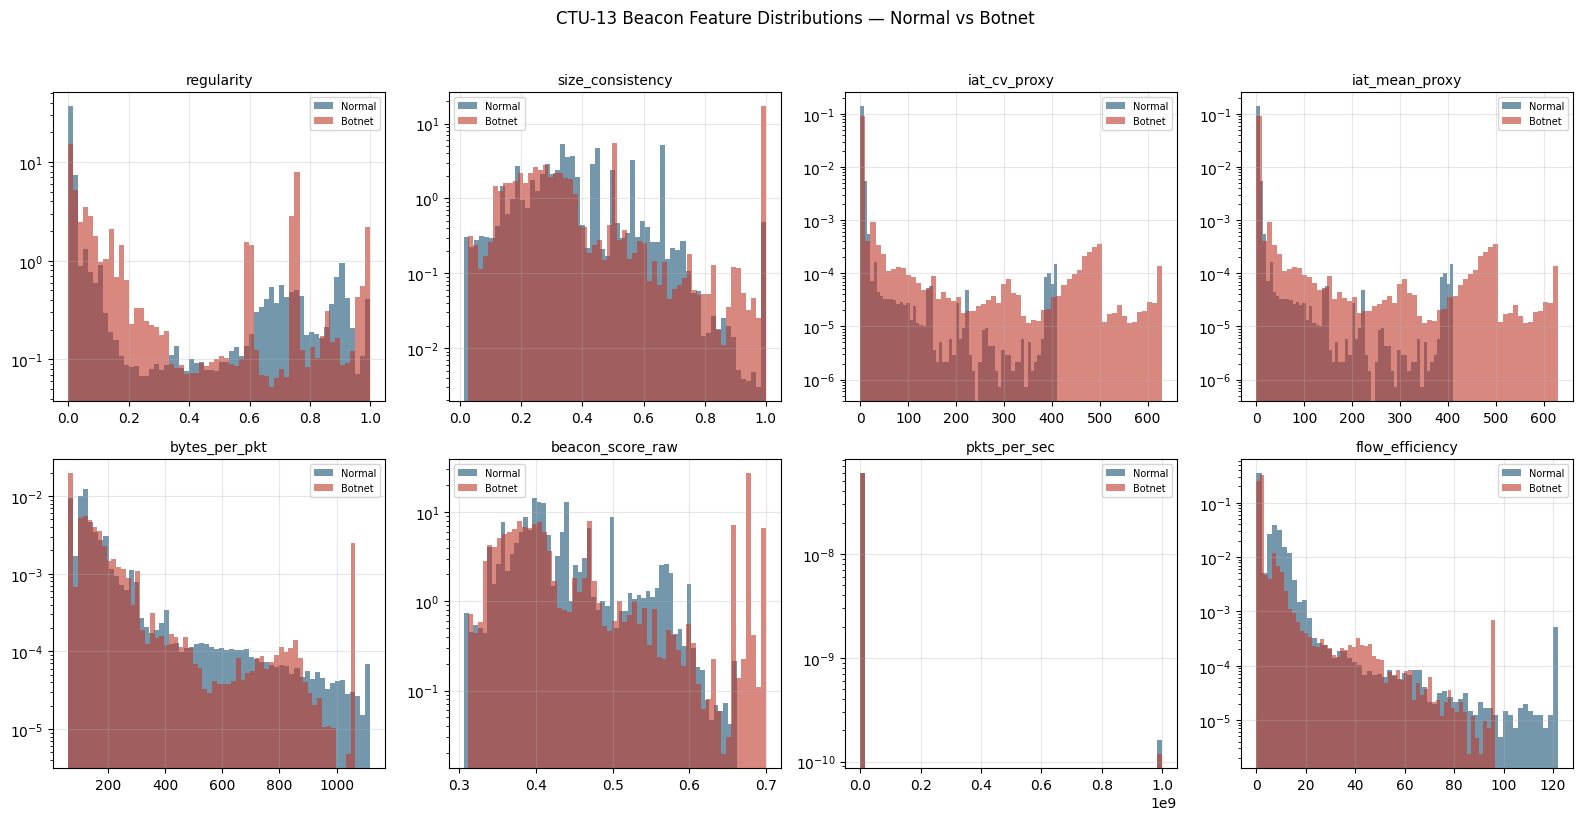

✓  Distribution plots saved


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 7 — Visualise beacon feature distributions
# ════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

plot_feats = ['regularity', 'size_consistency', 'iat_cv_proxy',
              'iat_mean_proxy', 'bytes_per_pkt', 'beacon_score_raw',
              'pkts_per_sec', 'flow_efficiency']

for ax, feat in zip(axes, plot_feats):
    for lbl, name, color in [(0,'Normal','#1A5276'), (1,'Botnet','#C0392B')]:
        vals = ctu.loc[ctu['binary_label']==lbl, feat]
        vals = vals[np.isfinite(vals)].clip(
            vals.quantile(0.001), vals.quantile(0.999)
        )
        ax.hist(vals, bins=60, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontsize=10)
    ax.set_yscale('log')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('CTU-13 Beacon Feature Distributions — Normal vs Botnet', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS}/ctu13_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓  Distribution plots saved")

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 8 — Train / test split and scale CTU-13
# ════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

rng = np.random.default_rng(42)

X = ctu[CTU_FEATURES].values.astype(np.float32)
y = ctu['binary_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler_ctu = RobustScaler()
X_train_sc = scaler_ctu.fit_transform(X_train)
X_test_sc  = scaler_ctu.transform(X_test)

print(f"Train : {len(X_train):,}  (botnet: {y_train.sum():,})")
print(f"Test  : {len(X_test):,}   (botnet: {y_test.sum():,})")
print(f"Features: {len(CTU_FEATURES)}")

Train : 372,097  (botnet: 210,058)
Test  : 93,025   (botnet: 52,515)
Features: 20


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 9 — Train Random Forest on CTU-13 (Layer 3 beacon detector)
# ════════════════════════════════════════════════════════════════════════
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, f1_score
)

print("Training CTU-13 Random Forest (Layer 3 beacon detector) ...")
print("This is the ONLY model PacketAgent uses for Layer 3.")
print()

t0 = time.time()
rf_ctu = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 20,
    min_samples_leaf = 2,
    n_jobs       = -1,
    random_state = 42,
    class_weight = 'balanced',
)
rf_ctu.fit(X_train_sc, y_train)
elapsed = time.time() - t0

print(f"✓  Trained in {elapsed:.1f}s")
print()

# Evaluate
rf_probs = rf_ctu.predict_proba(X_test_sc)[:, 1]
rf_preds = rf_ctu.predict(X_test_sc)

auc = roc_auc_score(y_test, rf_probs)
ap  = average_precision_score(y_test, rf_probs)
f1  = f1_score(y_test, rf_preds)

print("=" * 55)
print("CTU-13 Random Forest — Layer 3 Beacon Detector")
print("=" * 55)
print(f"  ROC-AUC              : {auc:.4f}")
print(f"  Average Precision    : {ap:.4f}")
print(f"  F1 Score             : {f1:.4f}")
print()
print(classification_report(
    y_test, rf_preds,
    target_names=['Normal', 'Botnet'], digits=4
))
print("=" * 55)

Training CTU-13 Random Forest (Layer 3 beacon detector) ...
This is the ONLY model PacketAgent uses for Layer 3.

✓  Trained in 330.8s

CTU-13 Random Forest — Layer 3 Beacon Detector
  ROC-AUC              : 0.9876
  Average Precision    : 0.9904
  F1 Score             : 0.9526

              precision    recall  f1-score   support

      Normal     0.9377    0.9396    0.9387     40510
      Botnet     0.9534    0.9519    0.9526     52515

    accuracy                         0.9465     93025
   macro avg     0.9455    0.9458    0.9456     93025
weighted avg     0.9466    0.9465    0.9465     93025



In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 10 — Train Isolation Forest on CTU-13 (unsupervised backup)
# ════════════════════════════════════════════════════════════════════════
from sklearn.ensemble import IsolationForest

print("Training CTU-13 Isolation Forest (unsupervised backup) ...")

# Train only on normal (label=0) data
normal_mask  = y_train == 0
X_train_norm = X_train_sc[normal_mask]

t0 = time.time()
if_ctu = IsolationForest(
    n_estimators = 200,
    contamination = 0.01,
    random_state  = 42,
    n_jobs        = -1,
)
if_ctu.fit(X_train_norm)
elapsed = time.time() - t0
print(f"✓  Isolation Forest trained in {elapsed:.1f}s")

if_preds_raw = if_ctu.predict(X_test_sc)
if_preds     = (if_preds_raw == -1).astype(int)  # -1 = anomaly = 1
if_acc       = (if_preds == y_test).mean()
print(f"  Accuracy (unsupervised on labelled test) : {if_acc:.3f}")
print(f"  NOTE: ~50% is expected for unsupervised on balanced data")

Training CTU-13 Isolation Forest (unsupervised backup) ...
✓  Isolation Forest trained in 2.7s
  Accuracy (unsupervised on labelled test) : 0.453
  NOTE: ~50% is expected for unsupervised on balanced data


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 11 — Load CICIDS-2018 Friday  (only if CSV was found in Cell 3)
# NOTE: XGBoost on CICIDS is SUPPLEMENTARY — the core C4 detection is
# the JA3/JA3S layers (live feed) + CTU-13 RF (Layer 3).
# PacketAgent.load() does NOT require XGBoost artifacts.
# ════════════════════════════════════════════════════════════════════════
import gc
from pathlib import Path

if SKIP_XGB:
    print("Skipping CICIDS load (SKIP_XGB=True from Cell 3).")
else:
    print(f"Loading CICIDS from: {os.path.basename(CICIDS_CSV)}")
    chunks = []
    from tqdm import tqdm

    for chunk in tqdm(
        pd.read_csv(
            CICIDS_CSV,
            chunksize=100_000,
            low_memory=False,
            na_values=['Infinity', 'infinity', 'inf', '-Infinity', '-inf', ''],
        ),
        desc='Loading CICIDS'
    ):
        chunk.columns = chunk.columns.str.strip()
        chunk.dropna(subset=['Label'], inplace=True)
        chunk['Label'] = chunk['Label'].str.strip()
        before  = len(chunk)
        chunk   = chunk[chunk['Label'].isin(['Bot', 'BENIGN'])].copy()
        chunk['binary_label'] = (chunk['Label'] == 'Bot').astype(np.int8)
        chunk.drop(columns=['Label'], inplace=True)
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunks.append(chunk)

    cicids = pd.concat(chunks, ignore_index=True)
    del chunks; gc.collect()

    print(f"Rows loaded : {len(cicids):,}")
    vc = cicids['binary_label'].value_counts()
    print(f"BENIGN: {vc.get(0,0):,}  Bot: {vc.get(1,0):,}")


Loading CICIDS from: Wednesday-workingHours.pcap_ISCX.csv


Loading CICIDS: 7it [00:20,  2.88s/it]


Rows loaded : 440,031
BENIGN: 440,031  Bot: 0


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 12 — CICIDS feature engineering (only if CSV was found)
# ════════════════════════════════════════════════════════════════════════
if not SKIP_XGB:
    eps = 1e-9

    # IAT-based beacon features (Layer 3 understanding)
    cicids['iat_cv']     = cicids['Flow IAT Std']  / (cicids['Flow IAT Mean'].abs() + eps)
    cicids['fwd_iat_cv'] = cicids['Fwd IAT Std']   / (cicids['Fwd IAT Mean'].abs()  + eps)
    cicids['bwd_iat_cv'] = cicids['Bwd IAT Std']   / (cicids['Bwd IAT Mean'].abs()  + eps)
    cicids['bytes_per_pkt'] = (
        cicids['Total Length of Fwd Packets'] + cicids['Total Length of Bwd Packets']
    ) / (cicids['Total Fwd Packets'] + cicids['Total Backward Packets'] + 1)
    cicids['bwd_fwd_ratio'] = cicids['Total Backward Packets'] / (cicids['Total Fwd Packets'] + 1)

    # Impute remaining NaN
    numeric_cols = cicids.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != 'binary_label']
    for col in numeric_cols:
        if cicids[col].isna().any():
            cicids[col] = cicids[col].fillna(cicids[col].median())

    # Clip at 99.9th percentile
    for col in numeric_cols:
        lo = cicids[col].quantile(0.001)
        hi = cicids[col].quantile(0.999)
        cicids[col] = cicids[col].clip(lower=lo, upper=hi)

    CICIDS_FEATURES = numeric_cols
    print(f"CICIDS features: {len(CICIDS_FEATURES)}")

    # IAT threshold analysis for Layer 3
    print("\nLayer 3 IAT CV threshold analysis:")
    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
    for t in thresholds:
        pred = (cicids['iat_cv'] < t).astype(int)
        tp   = ((pred==1) & (cicids['binary_label']==1)).sum()
        fp   = ((pred==1) & (cicids['binary_label']==0)).sum()
        fn   = ((pred==0) & (cicids['binary_label']==1)).sum()
        prec = tp / (tp + fp + eps)
        rec  = tp / (tp + fn + eps)
        f1_t = 2 * prec * rec / (prec + rec + eps)
        print(f"  IAT_CV < {t:.1f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1_t:.3f}")

CICIDS features: 85

Layer 3 IAT CV threshold analysis:
  IAT_CV < 0.1  Prec=0.000  Rec=0.000  F1=0.000
  IAT_CV < 0.2  Prec=0.000  Rec=0.000  F1=0.000
  IAT_CV < 0.3  Prec=0.000  Rec=0.000  F1=0.000
  IAT_CV < 0.4  Prec=0.000  Rec=0.000  F1=0.000
  IAT_CV < 0.5  Prec=0.000  Rec=0.000  F1=0.000


In [ ]:
if not SKIP_XGB:
    print(cicids.columns.tolist())

['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH 

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 13 — Train XGBoost on CICIDS-2018 (only if CSV was found)
# ════════════════════════════════════════════════════════════════════════
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score
)

if not SKIP_XGB:
    X_cic = cicids[CICIDS_FEATURES].values.astype(np.float32)
    y_cic = cicids['binary_label'].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_cic, y_cic, test_size=0.20, random_state=42, stratify=y_cic
    )

    scaler_cic = RobustScaler()
    X_tr_sc    = scaler_cic.fit_transform(X_tr)
    X_te_sc    = scaler_cic.transform(X_te)

    xgb_model = xgb.XGBClassifier(
        n_estimators     = 200,
        max_depth        = 8,
        learning_rate    = 0.02,
        subsample        = 0.8,
        colsample_bytree = 0.9,
        use_label_encoder = False,
        eval_metric      = 'logloss',
        random_state     = 42,
        n_jobs           = -1,
        device           = 'cuda' if gpu else 'cpu',
    )

    print("Training XGBoost on CICIDS-2018 ...")
    t0 = time.time()
    xgb_model.fit(
        X_tr_sc, y_tr,
        eval_set=[(X_te_sc, y_te)],
        verbose=50,
    )
    print(f"✓  Trained in {time.time()-t0:.1f}s")

    xgb_probs  = xgb_model.predict_proba(X_te_sc)[:, 1]
    xgb_thresh = 0.4868   # from your notebook's optimal threshold

    xgb_preds = (xgb_probs >= xgb_thresh).astype(int)
    auc_xgb   = roc_auc_score(y_te, xgb_probs)
    print(f"\nXGBoost — ROC-AUC: {auc_xgb:.4f}")
    print(classification_report(y_te, xgb_preds,
          target_names=['Benign', 'Bot'], digits=4))

In [ ]:
SKIP_XGB = True

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 14 — Save all artifacts
# These are the EXACT filenames that PacketAgent.load() expects.
# ════════════════════════════════════════════════════════════════════════
import joblib, json

os.makedirs(MODELS, exist_ok=True)

# ── CTU-13 RF — Layer 3 beacon detector (REQUIRED) ─────────────────────
joblib.dump(rf_ctu,    f'{MODELS}/packet_rf_ctu.pkl')
joblib.dump(scaler_ctu,f'{MODELS}/packet_rf_scaler.pkl')
with open(f'{MODELS}/packet_rf_features.json', 'w') as fp:
    json.dump(CTU_FEATURES, fp, indent=2)

print(f"✓  packet_rf_ctu.pkl              ({os.path.getsize(f'{MODELS}/packet_rf_ctu.pkl')/1024:.0f} KB)")
print(f"✓  packet_rf_scaler.pkl           ({os.path.getsize(f'{MODELS}/packet_rf_scaler.pkl')/1024:.0f} KB)")
print(f"✓  packet_rf_features.json        ({len(CTU_FEATURES)} features)")

# ── CTU-13 IF — unsupervised backup (optional, not loaded by PacketAgent) ──
joblib.dump(if_ctu, f'{MODELS}/packet_if_ctu.pkl')
print(f"✓  packet_if_ctu.pkl              (optional, not used by PacketAgent)")

# ── Evaluation metrics ─────────────────────────────────────────────────
metrics = {
    "rf_ctu_auc":  float(roc_auc_score(y_test, rf_ctu.predict_proba(X_test_sc)[:,1])),
    "rf_ctu_ap":   float(average_precision_score(y_test, rf_ctu.predict_proba(X_test_sc)[:,1])),
    "rf_ctu_f1":   float(f1_score(y_test, rf_ctu.predict(X_test_sc))),
    "ctu_features": CTU_FEATURES,
    "n_train": len(X_train),
    "n_test":  len(X_test),
}
with open(f'{MODELS}/packet_metrics.json', 'w') as fp:
    json.dump(metrics, fp, indent=2)
print(f"✓  packet_metrics.json")

# ── XGBoost CICIDS artifacts (if trained) ──────────────────────────────
if not SKIP_XGB:
    joblib.dump(xgb_model,  f'{MODELS}/packet_xgb_cicids.pkl')
    joblib.dump(scaler_cic, f'{MODELS}/packet_xgb_scaler.pkl')
    with open(f'{MODELS}/packet_xgb_features.json', 'w') as fp:
        json.dump(CICIDS_FEATURES, fp, indent=2)
    with open(f'{MODELS}/packet_xgb_threshold.pkl', 'wb') as fp:
        pickle.dump(xgb_thresh, fp)
    print(f"✓  packet_xgb_cicids.pkl")
    print(f"✓  packet_xgb_scaler.pkl")
    print(f"✓  packet_xgb_features.json")
    print(f"✓  packet_xgb_threshold.pkl  (threshold={xgb_thresh})")

print(f"\nAll saved to: {MODELS}")

✓  packet_rf_ctu.pkl              (272652 KB)
✓  packet_rf_scaler.pkl           (1 KB)
✓  packet_rf_features.json        (20 features)
✓  packet_if_ctu.pkl              (optional, not used by PacketAgent)
✓  packet_metrics.json

All saved to: /content/drive/MyDrive/banksentinel/models


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 15 — Verify: reload and score test samples
# ════════════════════════════════════════════════════════════════════════
import pickle

# Reload
rf_reload   = joblib.load(f'{MODELS}/packet_rf_ctu.pkl')
scl_reload  = joblib.load(f'{MODELS}/packet_rf_scaler.pkl')
with open(f'{MODELS}/packet_rf_features.json') as fp:
    feats_reload = json.load(fp)

print(f"✓  RF reloaded  ({len(feats_reload)} features)")

# Score 10 balanced samples
b_idx   = np.where(y_test == 0)[0]
m_idx   = np.where(y_test == 1)[0]
s_idx   = np.concatenate([
    rng.choice(b_idx, 5, replace=False),
    rng.choice(m_idx, 5, replace=False),
])
X_s     = scl_reload.transform(X_test[s_idx])
probs_s = rf_reload.predict_proba(X_s)[:, 1]
preds_s = rf_reload.predict(X_s)
labels_s = y_test[s_idx]

print(f"\n{'#':>3}  {'True':>8}  {'Prob':>8}  {'Pred':>10}  {'Verdict':>12}")
print("  " + "─" * 48)
for i in range(10):
    true  = "Botnet"  if labels_s[i] == 1 else "Normal"
    pred  = "Botnet"  if preds_s[i]  == 1 else "Normal"
    v     = "✓ Correct" if preds_s[i] == labels_s[i] else "✗ Wrong"
    print(f"  {i+1:>3}  {true:>8}  {probs_s[i]:>8.4f}  {pred:>10}  {v:>12}")

acc = (preds_s == labels_s).mean()
print(f"\n  Accuracy on 10 samples: {acc:.1%}")
print(f"  RF AUC on full test: {metrics['rf_ctu_auc']:.4f}")

✓  RF reloaded  (20 features)

  #      True      Prob        Pred       Verdict
  ────────────────────────────────────────────────
    1    Normal    0.0000      Normal     ✓ Correct
    2    Normal    0.0606      Normal     ✓ Correct
    3    Normal    0.0000      Normal     ✓ Correct
    4    Normal    0.0989      Normal     ✓ Correct
    5    Normal    0.3044      Normal     ✓ Correct
    6    Botnet    0.9900      Botnet     ✓ Correct
    7    Botnet    0.9841      Botnet     ✓ Correct
    8    Botnet    1.0000      Botnet     ✓ Correct
    9    Botnet    0.9353      Botnet     ✓ Correct
   10    Botnet    0.9969      Botnet     ✓ Correct

  Accuracy on 10 samples: 100.0%
  RF AUC on full test: 0.9876


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CELL 16 — Download artifacts to local machine
# ════════════════════════════════════════════════════════════════════════
from google.colab import files

REQUIRED = [
    'packet_rf_ctu.pkl',
    'packet_rf_scaler.pkl',
    'packet_rf_features.json',
    'packet_metrics.json',
]
OPTIONAL = [
    'packet_xgb_cicids.pkl',
    'packet_xgb_scaler.pkl',
    'packet_xgb_features.json',
    'packet_xgb_threshold.pkl',
    'packet_if_ctu.pkl',
]

print("Downloading REQUIRED files (PacketAgent.load() needs these):")
for fname in REQUIRED:
    path = f'{MODELS}/{fname}'
    if os.path.exists(path):
        files.download(path)
        sz = os.path.getsize(path) / 1024
        print(f"  ↓  {fname}  ({sz:.0f} KB)")
    else:
        print(f"  ✗  {fname}  NOT FOUND")

print("\nDownloading OPTIONAL files:")
for fname in OPTIONAL:
    path = f'{MODELS}/{fname}'
    if os.path.exists(path):
        files.download(path)
        sz = os.path.getsize(path) / 1024
        print(f"  ↓  {fname}  ({sz:.0f} KB)")

print("\n" + "=" * 55)
print("Place all downloaded files in:  banksentinel/models/")
print("Then run:  python -m pytest tests/test_packet_agent.py -v")
print("=" * 55)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓  packet_rf_ctu.pkl  (272652 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ↓  packet_metrics.json  (1 KB)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓  packet_if_ctu.pkl  (1690 KB)

Place all downloaded files in:  banksentinel/models/
Then run:  python -m pytest tests/test_packet_agent.py -v
